Análisis de Sentimiento No Supervisado


In [1]:
import sqlite3, re, os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from langdetect import detect
from sklearn.preprocessing import normalize
import emoji
import umap
import plotly.express as px
import plotly.graph_objects as go
from collections import Counter
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

DB_PATH = '../db/gaming_warehouse.db'
print('Listo calisto')

c:\Users\ADRIA\OneDrive\Escritorio\Descargar_datos\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Listo calisto


In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 600)

## 1 · Carga de datos

In [3]:
def Query(query):
    conn = sqlite3.connect(DB_PATH)
    df = pd.read_sql_query(query, conn)
    conn.close()
    return df


In [4]:
Query("SELECT name FROM sqlite_master WHERE type='table' order by name")

,name
0,CAT_Empresa
1,CAT_Etiqueta
2,CAT_Franquicia
3,CAT_Genero
4,CAT_ITAD_Juego
5,CAT_Juego
6,CAT_Modo_Juego
7,CAT_Perspectiva
8,CAT_Plataforma
9,CAT_Tematica


In [5]:
Query("Select * from CAT_Juego").head()

,juego_id,id_igdb,id_steam,titulo,categoria,fecha_lanzamiento,resumen,historia,url_portada,puntuacion_igdb,conteo_votos_igdb,conteo_dlc,conteo_videos,hltb_historia_principal,hltb_historia_extra,hltb_completacionista,steam_price_initial,steam_price_final,steam_discount_percent,metacritic_score,recommendations_count,achievements_count,steam_languages,pc_requirements_json
0,1,1020,NaN,Grand Theft Auto V,0,2013-09-17,"Grand Theft Auto V is a vast open world game set in Los Santos, a sprawling sun-soaked metropolis struggling to stay afloat in an era of economic uncertainty and cheap reality TV. The game blends storytelling and gameplay in new ways as players repeatedly jump in and out of the lives of the game’s three lead characters, playing all sides of the game’s interwoven story.","Los Santos: a sprawling sun-soaked metropolis full of self-help gurus, starlets and fading celebrities, once the envy of the Western world, now struggling to stay afloat in an era of economic uncertainty and cheap reality TV.\n\nAmidst the turmoil, three very different criminals plot their own chances of survival and success: Franklin, a street hustler looking for real opportunities and serious money; Michael, a professional ex-con whose retirement is a lot less rosy than he hoped it would be; and Trevor, a violent maniac driven by the chance of a cheap high and the next big score. Running...",https://images.igdb.com/igdb/image/upload/t_cover_big/co2lbd.jpg,89.611577,5615,0,4,32.06,51.48,88.36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1942,292030.0,The Witcher 3: Wild Hunt,0,2015-05-19,"The Witcher 3: Wild Hunt is an open-world action role-playing game developed by CD Projekt Red.\n\nSet in a dark fantasy world, the game follows Geralt of Rivia, a monster hunter searching for his adopted daughter, Ciri, while navigating political conflicts and supernatural threats. Gameplay features exploration, combat, character progression, and branching narratives shaped by player choices. Widely acclaimed for its writing, world-building, and depth, it is considered one of the most influential RPGs of its generation.","The Witcher 3: Wild Hunt concludes the story of the witcher Geralt of Rivia, the series' protagonist, whose story to date has been covered in the previous installments. Geralt's new mission comes in dark times as the mysterious and otherworldly army known as the Wild Hunt invades the Northern Kingdoms, leaving only blood soaked earth and fiery ruin in its wake; and it seems the Witcher is the key to stopping their cataclysmic rampage.",https://images.igdb.com/igdb/image/upload/t_cover_big/coaarl.jpg,93.790730,5179,5,17,51.60,103.76,174.49,499.00,499.00,0.0,93.0,811062.0,78.0,"Inglés<strong>*</strong>, Francés<strong>*</strong>, Italiano, Alemán<strong>*</strong>, Español de España, Árabe, Checo, Húngaro, Japonés<strong>*</strong>, Coreano<strong>*</strong>, Polaco<strong>*</strong>, Portugués de Brasil<strong>*</strong>, Ruso<strong>*</strong>, Chino tradicional, Turco, Chino simplificado<strong>*</strong>, Español de Hispanoamérica<br><strong>*</strong>idiomas con localización de audio","{""minimum"": ""<strong>M\u00ednimo:</strong><br><ul class=\""bb_ul\""><li><strong>SO *:</strong> 64-bit Windows 7, 64-bit Windows 8 (8.1)<br></li><li><strong>Procesador:</strong> Intel CPU Core i5-2500K 3.3GHz / AMD A10-5800K APU (3.8GHz)<br></li><li><strong>Memoria:</strong> 6 GB de RAM<br></li><li><strong>Gr\u00e1ficos:</strong> Nvidia GPU GeForce GTX 660 / AMD GPU Radeon HD 7870<br></li><li><strong>DirectX:</strong> Versi\u00f3n 11<br></li><li><strong>Almacenamiento:</strong> 50 GB de espacio disponible</li></ul>"", ""recommended"": ""<strong>Recomendado:</strong><br><ul class=\""bb_ul\""><li><st..."
2,3,72,620.0,Portal 2,0,2011-04-18,"Sequel to the acclaimed Portal (2007), Portal 2 pits the protagonist of the original game, Chell, and her new robot friend, Wheatley, against more puzzles conceived by GLaDOS, an A.I. with the sole purpose of testing the Portal Gun's m

In [6]:
df_reseñas=Query("Select * from cat_juego  y join Hist_Steam_Reviews x on x.juego_id=y.juego_id")

In [7]:
df_reseñas.shape

(557907, 38)

In [8]:
# from langdetect import detect

# def es_espanol(texto):
#     try:
#         return detect(str(texto)) == 'es'
#     except:
#         return False

# df_reseñas = df_reseñas[df_reseñas['resena_texto'].apply(es_espanol)]

In [9]:
df_reseñas.shape

(557907, 38)

In [10]:
df_reseñas.columns

Index(['juego_id', 'id_igdb', 'id_steam', 'titulo', 'categoria',
       'fecha_lanzamiento', 'resumen', 'historia', 'url_portada',
       'puntuacion_igdb', 'conteo_votos_igdb', 'conteo_dlc', 'conteo_videos',
       'hltb_historia_principal', 'hltb_historia_extra',
       'hltb_completacionista', 'steam_price_initial', 'steam_price_final',
       'steam_discount_percent', 'metacritic_score', 'recommendations_count',
       'achievements_count', 'steam_languages', 'pc_requirements_json',
       'resena_id', 'juego_id', 'resena_texto', 'recomendado', 'votos_utiles',
       'votos_graciosos', 'puntuacion_ponderada', 'minutos_al_resenar',
       'minutos_totales', 'fecha_creacion_unix', 'autor_num_resenas',
       'autor_num_juegos', 'recibido_gratis', 'escrito_acceso_anticipado'],
      dtype='str')

In [11]:
columnas=['juego_id', 'id_igdb', 'id_steam', 'titulo','resena_id', 'resena_texto','categoria',
       'fecha_lanzamiento', 'resumen', 'historia','conteo_votos_igdb', 'conteo_dlc', 'conteo_videos',
       'hltb_historia_principal', 'hltb_historia_extra',
       'hltb_completacionista','recommendations_count',
       'achievements_count',
         'recomendado', 'votos_utiles',
       'votos_graciosos', 'puntuacion_ponderada', 'minutos_al_resenar',
       'minutos_totales', 'fecha_creacion_unix', 'autor_num_resenas',
       'autor_num_juegos', 'recibido_gratis', 'escrito_acceso_anticipado']
df_reseñas[columnas]

,juego_id,juego_id,id_igdb,id_steam,titulo,resena_id,resena_texto,categoria,fecha_lanzamiento,resumen,historia,conteo_votos_igdb,conteo_dlc,conteo_videos,hltb_historia_principal,hltb_historia_extra,hltb_completacionista,recommendations_count,achievements_count,recomendado,votos_utiles,votos_graciosos,puntuacion_ponderada,minutos_al_resenar,minutos_totales,fecha_creacion_unix,autor_num_resenas,autor_num_juegos,recibido_gratis,escrito_acceso_anticipado
0,445,445,242408,730,Counter-Strike 2,222607893,una mierda,0,2023-09-27,"For over two decades, Counter-Strike has offered an elite competitive experience, one shaped by millions of players from across the globe. And now the next chapter in the CS story is about to begin. This is Counter-Strike 2.\n\nA free upgrade to CS:GO, Counter-Strike 2 marks the largest technical leap in Counter-Strike’s history. Built on the Source 2 engine, Counter-Strike 2 is modernized with realistic physically-based rendering, state of the art networking, and upgraded Community Workshop tools.",Sin datos,320,0,5,147.77,373.06,755.52,5017015,1,0,0,0,0.500000,950,950.0,1775416375,1,0,0,0
1,445,445,242408,730,Counter-Strike 2,222596476,"Juego LLENO de chiteros, con una comunidad de jugadores muy hijo de perra. Jueguen otros juegos.",0,2023-09-27,"For over two decades, Counter-Strike has offered an elite competitive experience, one shaped by millions of players from across the globe. And now the next chapter in the CS story is about to begin. This is Counter-Strike 2.\n\nA free upgrade to CS:GO, Counter-Strike 2 marks the largest technical leap in Counter-Strike’s history. Built on the Source 2 engine, Counter-Strike 2 is modernized with realistic physically-based rendering, state of the art networking, and upgraded Community Workshop tools.",Sin datos,320,0,5,147.77,373.06,755.52,5017015,1,0,1,0,0.523810,1231,1231.0,1775407333,1,0,0,0
2,445,445,242408,730,Counter-Strike 2,222560877,esta muy pero que muy bueno jugarlo,0,2023-09-27,"For over two decades, Counter-Strike has offered an elite competitive experience, one shaped by millions of players from across the globe. And now the next chapter in the CS story is about to begin. This is Counter-Strike 2.\n\nA free upgrade to CS:GO, Counter-Strike 2 marks the largest technical leap in Counter-Strike’s history. Built on the Source 2 engine, Counter-Strike 2 is modernized with realistic physically-based rendering, state of the art networking, and upgraded Community Workshop tools.",Sin datos,320,0,5,147.77,373.06,755.52,5017015,1,1,0,0,0.500000,8892,8894.0,1775374769,2,9,0,0
3,445,445,242408,730,Counter-Strike 2,222558751,Me enojo mucho pero buen juego,0,2023-09-27,"For over two decades, Counter-Strike has offered an elite competitive experience, one shaped by millions of players from across the globe. And now the next chapter in the CS story is about to begin. This is Counter-Strike 2.\n\nA free upgrade to CS:GO, Counter-Strike 2 marks the largest technical leap in Counter-Strike’s history. Built on the Source 2 engine, Counter-Strike 2 is modernized with realistic physically-based rendering, state of the art networking, and upgraded Community Workshop tools.",Sin datos,320,0,5,147.77,373.06,755.52,5017015,1,1,0,0,0.500000,1783,1783.0,1775372012,1,0,0,0
4,445,445,242408,730,Counter-Strike 2,222554976,es como cojer sin forro\r\n,0,2023-09-27,"For over two decades, Counter-Strike has offered an elite competitive experience, one shaped by millions of players from across the globe. And now the next chapter in the CS story is about to begin. This is Counter-Strike 2.\n\nA free upgrade to CS:GO, Counter-Strike 2 marks the largest technical leap in Counter-Strike’s history. Built on the Source 2 engine, Counter-Strike 2 is modernized with realistic physically-based rendering, state of the art networking, and upgraded Community Workshop tools.",Sin datos,320,0,5,147.77,373.06,755.52,5017015,1,1,0,0,0.500000,7092,7132.0,1775367242,2,0,0,0
...,...,...,...,...,...,...,...,

In [12]:
df_reseñas[df_reseñas['titulo']=='Cyberpunk 2077'][columnas].head(10)
#diferentes juegos me muestran un buen lote de reseñas pero steam al parcer no tiene filtro y eso hace que haya 
# reseñas bastante con palasbras mal sonantes, sexualisando personajes, eventos o emociones
# se hara un revision con tf-idf para ver que arroja los datos

,juego_id,juego_id,id_igdb,id_steam,titulo,resena_id,resena_texto,categoria,fecha_lanzamiento,resumen,historia,conteo_votos_igdb,conteo_dlc,conteo_videos,hltb_historia_principal,hltb_historia_extra,hltb_completacionista,recommendations_count,achievements_count,recomendado,votos_utiles,votos_graciosos,puntuacion_ponderada,minutos_al_resenar,minutos_totales,fecha_creacion_unix,autor_num_resenas,autor_num_juegos,recibido_gratis,escrito_acceso_anticipado
8000,60,60,1877,1091500,Cyberpunk 2077,222584631,goat,0,2020-12-10,"Cyberpunk 2077 is an open-world action-adventure game set in Night City, a sprawling metropolis driven by power, glamour, and body modification. Players assume the role of V, a mercenary outlaw in pursuit of a unique implant that holds the key to immortality. The game allows extensive customization of cyberware, skills, and playstyle. Choices made throughout the journey influence both the narrative and the world.","In 2077, following an economic collapse sometime during the early 21st century, the United States is forced to rely on large corporations to survive. These corporations deal in a wide range of areas, such as weapons, robotics, cybernetics, pharmaceuticals, communications and biotechnology, and many of these companies operate above the law. The world in between is where decadence, sex and pop culture mix with violent crime, extreme poverty and the unattainable promise of the American Dream. You play as V, a mercenary outlaw deeply embedded in the crime-ridden city of Night City, going after...",1473,0,20,26.0,63.04,108.27,840457,57,1,0,0,0.5,10602,10683.0,1775398350,4,260,0,0
8001,60,60,1877,1091500,Cyberpunk 2077,222560591,Gran juego comprenlo con el dlc vale la pena,0,2020-12-10,"Cyberpunk 2077 is an open-world action-adventure game set in Night City, a sprawling metropolis driven by power, glamour, and body modification. Players assume the role of V, a mercenary outlaw in pursuit of a unique implant that holds the key to immortality. The game allows extensive customization of cyberware, skills, and playstyle. Choices made throughout the journey influence both the narrative and the world.","In 2077, following an economic collapse sometime during the early 21st century, the United States is forced to rely on large corporations to survive. These corporations deal in a wide range of areas, such as weapons, robotics, cybernetics, pharmaceuticals, communications and biotechnology, and many of these companies operate above the law. The world in between is where decadence, sex and pop culture mix with violent crime, extreme poverty and the unattainable promise of the American Dream. You play as V, a mercenary outlaw deeply embedded in the crime-ridden city of Night City, going after...",1473,0,20,26.0,63.04,108.27,840457,57,1,0,0,0.5,320,320.0,1775374378,19,75,0,0
8002,60,60,1877,1091500,Cyberpunk 2077,222560483,mejor que el sexo,0,2020-12-10,"Cyberpunk 2077 is an open-world action-adventure game set in Night City, a sprawling metropolis driven by power, glamour, and body modification. Players assume the role of V, a mercenary outlaw in pursuit of a unique implant that holds the key to immortality. The game allows extensive customization of cyberware, skills, and playstyle. Choices made throughout the journey influence both the narrative and the world.","In 2077, following an economic collapse sometime during the early 21st century, the United States is forced to rely on large corporations to survive. These corporations deal in a wide range of areas, such as weapons, robotics, cybernetics, pharmaceuticals, communications and biotechnology, and many of these companies operate above the law. The world in between is where decadence, sex and pop culture mix with violent crime, extreme poverty and the unattainable promise of the American Dream. You play as V, a mercenary outlaw deeply embedded in the crime-ridden city of Night City, going after...",1473,0,20,26.0,63.04,108.27,840457,57,1,0,0,0.5,7954,7954.0,177537

In [13]:
# siendo una marca de comics y de califacion de afolesctes pude que no me encuentre reviews tan atipicas
JUEGO_NOMBRE = 'Batman: Arkham City - Game of the Year Edition'

conn = sqlite3.connect(DB_PATH)
juego = pd.read_sql_query(
    "SELECT juego_id, titulo FROM CAT_Juego WHERE titulo LIKE ?",
    conn, params=(f'%{JUEGO_NOMBRE}%',)
)
print(juego)
conn.close()

   juego_id                                          titulo
0      1015  Batman: Arkham City - Game of the Year Edition


In [14]:
JUEGO_ID = int(juego['juego_id'].iloc[0])
JUEGO_ID

1015

In [15]:
print(f'Usando juego_id={JUEGO_ID}: {juego["titulo"].iloc[0]}')

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("""
    SELECT resena_id, resena_texto, recomendado,
           votos_utiles, fecha_creacion_unix
    FROM Hist_Steam_Reviews
    WHERE juego_id = ?
     -- AND resena_texto IS NOT NULL
      --AND length(trim(resena_texto)) > 20
""", conn, params=(JUEGO_ID,))
conn.close()

#calramaente tendre que abordar los comentarios soeces porque si pude que den informacion, algunas veces
# pero tampoc se la pueda dar asi como asi
#al usuario
df[df['recomendado']==0]

Usando juego_id=1015: Batman: Arkham City - Game of the Year Edition


,resena_id,resena_texto,recomendado,votos_utiles,fecha_creacion_unix
25,219815219,Pereza me dio seguir jugando esto.,0,0,1772645934
36,218503222,"Me gusto mas el arkam asylum, este tiene misiones de desactiva 3 cosas, activa 3 cosas y asi con cada mision, el dlc es igual muy repetitivo",0,0,1771288357
50,216664667,"no se puede tener sexo con catwoman, mal juego",0,0,1769236402
143,203978515,"ya no funciona, desde hace casi dos años que no lo arreglan. No arranca ni tampoco hay muchas opciones para arreglarlo manualmente.",0,0,1757458594
235,193128823,"Es una mierda, cuando empiezo una nueva partida y salta la escena de catwoman se me crashea todo y se cierra el juego\nuna perdida de dinero.",0,0,1745092505
250,190773618,JUEGO DE MRD NO LO PLATINEN POR LO QUE MAS QUIERAN PUTA JUEGO DE MRD OJALA SE BORRE PARA SIEMPRE,0,1,1742529811
277,187937955,Está en inglés ni títulos en español tiene 😔,0,1,1739599113
299,185456284,"Estoy asqueada de este juego. Me encantaba mucho la saga Arkham, hasta que veo que el ASQUEROSÍSIMO Acertijo usa SIEMPRE como base de operaciones una Iglesia. NO PUEDE SER. ¿No había acaso otro lugar? Me da rabia que siempre utilicen símbolos y lugares sagrados para nosotros los católicos como que fuesen cualquier cosa. Eso es pasar a llevar lo que es sagrado para los católicos. En ese caso, ¿Por qué no utilizan una mezquita, o un templo judío o budista? Se supone que debe haber respeto para todos, pero NO SE ATREVEN con otros porque si lo hacen, no están en esta tierra al otro día. IRRESP...",0,0,1736704293
361,175862336,"Entiendo que habrá mucha gente a la que le gustó el primero y le va a gustar esta secuela, pero yo siento que tomaron todo lo bueno de Batman: Arkham Asylum y lo empeoraron, simplemente agregando más de cada cosa hasta el hartazgo y sin arreglar los aspectos malos del primero.\n\nEl primero tenía acertijos a resolver? Este tiene cien veces más acertijos, que no solo son demasiados sino que rompen la inmersión. Llenaron toda la ciudad de porquería fluorescente que no se puede sacar de la vista de uno en ningún momento.\n\nEl primero tenía diálogos interesantes entre los NPCs? En este no sol...",0,0,1727426193
425,168036193,"Como persona que tiene mucho sexo a toda hora, puedo decir que este juego es 100% parecido a tener sexo con una mujer, como yo siempre hago. Obviamente este juego no me puso caliente. no soy gay, yo tengo mucho sexo con mujeres reales como para gastar más de 15 minutos en este juego. Por otro lado me gustaría recomendar este juego a la gente que no tiene sexo (no como yo porque yo tengo mucho sexo con mujeres, mucho) como si ahí hubiese una mujer desnuda y está desnuda. Ella también se ve como una de mis varias novias con la que tuve mucho sexo. He tenido mucho sexo. También soy muy guapo ...",0,0,1719173056


## Limpieza de texto

In [16]:
STOPWORDS_ES = set(stopwords.words('spanish')) | {
    'juego', 'juegos', 'game', 'games', 'si', 'mas', 'asi',
    'ver', 'solo', 'bien', 'mal', 'muy', 'tan', 'ser', 'esta',
    'puede', 'tiene', 'hay', 'hace', 'haber', 'sido', 'ser',
    'aunque', 'igual', 'cada', 'pues', 'vez', 'veces',
}

def limpiar(texto: str) -> str:
    texto = texto.lower()
    texto = re.sub(r'http\S+', '', texto)
    texto = re.sub(r'[^a-záéíóúüñ\s]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    tokens = [t for t in texto.split() if t not in STOPWORDS_ES and len(t) > 2]
    return ' '.join(tokens)

df['texto_limpio'] = df['resena_texto'].astype(str).apply(limpiar)
df = df[df['texto_limpio'].str.len() > 10].reset_index(drop=True)
print(f'Reseñas tras limpieza: {len(df):,}')
#display(df[df['recomendado']==0]['texto_limpio'])

Reseñas tras limpieza: 741


## TF-IDF

In [17]:
tfidf = TfidfVectorizer(
    max_features=8000,
    min_df=5,
    max_df=0.85,
    ngram_range=(1, 3),
    sublinear_tf=True,
)
X_tfidf = tfidf.fit_transform(df['texto_limpio'])
print(X_tfidf.shape)


(741, 553)


Varianza explicada con 553 componentes: 100.00%


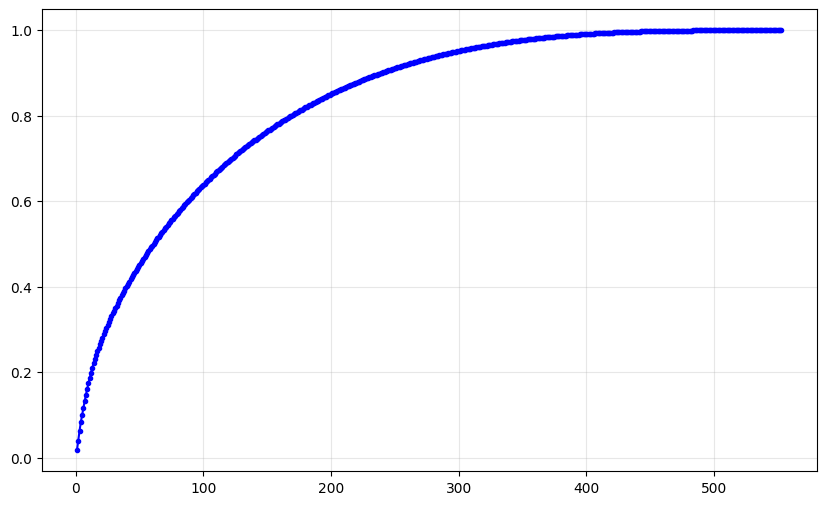

In [18]:
N_COMPONENTES = 553
svd = TruncatedSVD(n_components=N_COMPONENTES, random_state=31)
X_svd = svd.fit_transform(X_tfidf)
X_svd = normalize(X_svd)

varianza_acumulada = np.cumsum(svd.explained_variance_ratio_)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='.', linestyle='-', color='b')
plt.grid(True, alpha=0.3)

varianza = svd.explained_variance_ratio_.sum()
print(f'Varianza explicada con {N_COMPONENTES} componentes: {varianza:.2%}')

In [19]:
N_COMPONENTES = 250
svd = TruncatedSVD(n_components=N_COMPONENTES, random_state=31)
X_svd = svd.fit_transform(X_tfidf)
X_svd = normalize(X_svd)

## 4 · UMAP (visualización 2D)

In [20]:
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.05,
    metric='cosine',
    random_state=31,
    low_memory=False,
)
X_2d = reducer.fit_transform(X_svd)
df['umap_x'] = X_2d[:, 0]
df['umap_y'] = X_2d[:, 1]
print('UMAP listo')

c:\Users\ADRIA\OneDrive\Escritorio\Descargar_datos\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP listo


## 5 · KMeans — búsqueda del K óptimo

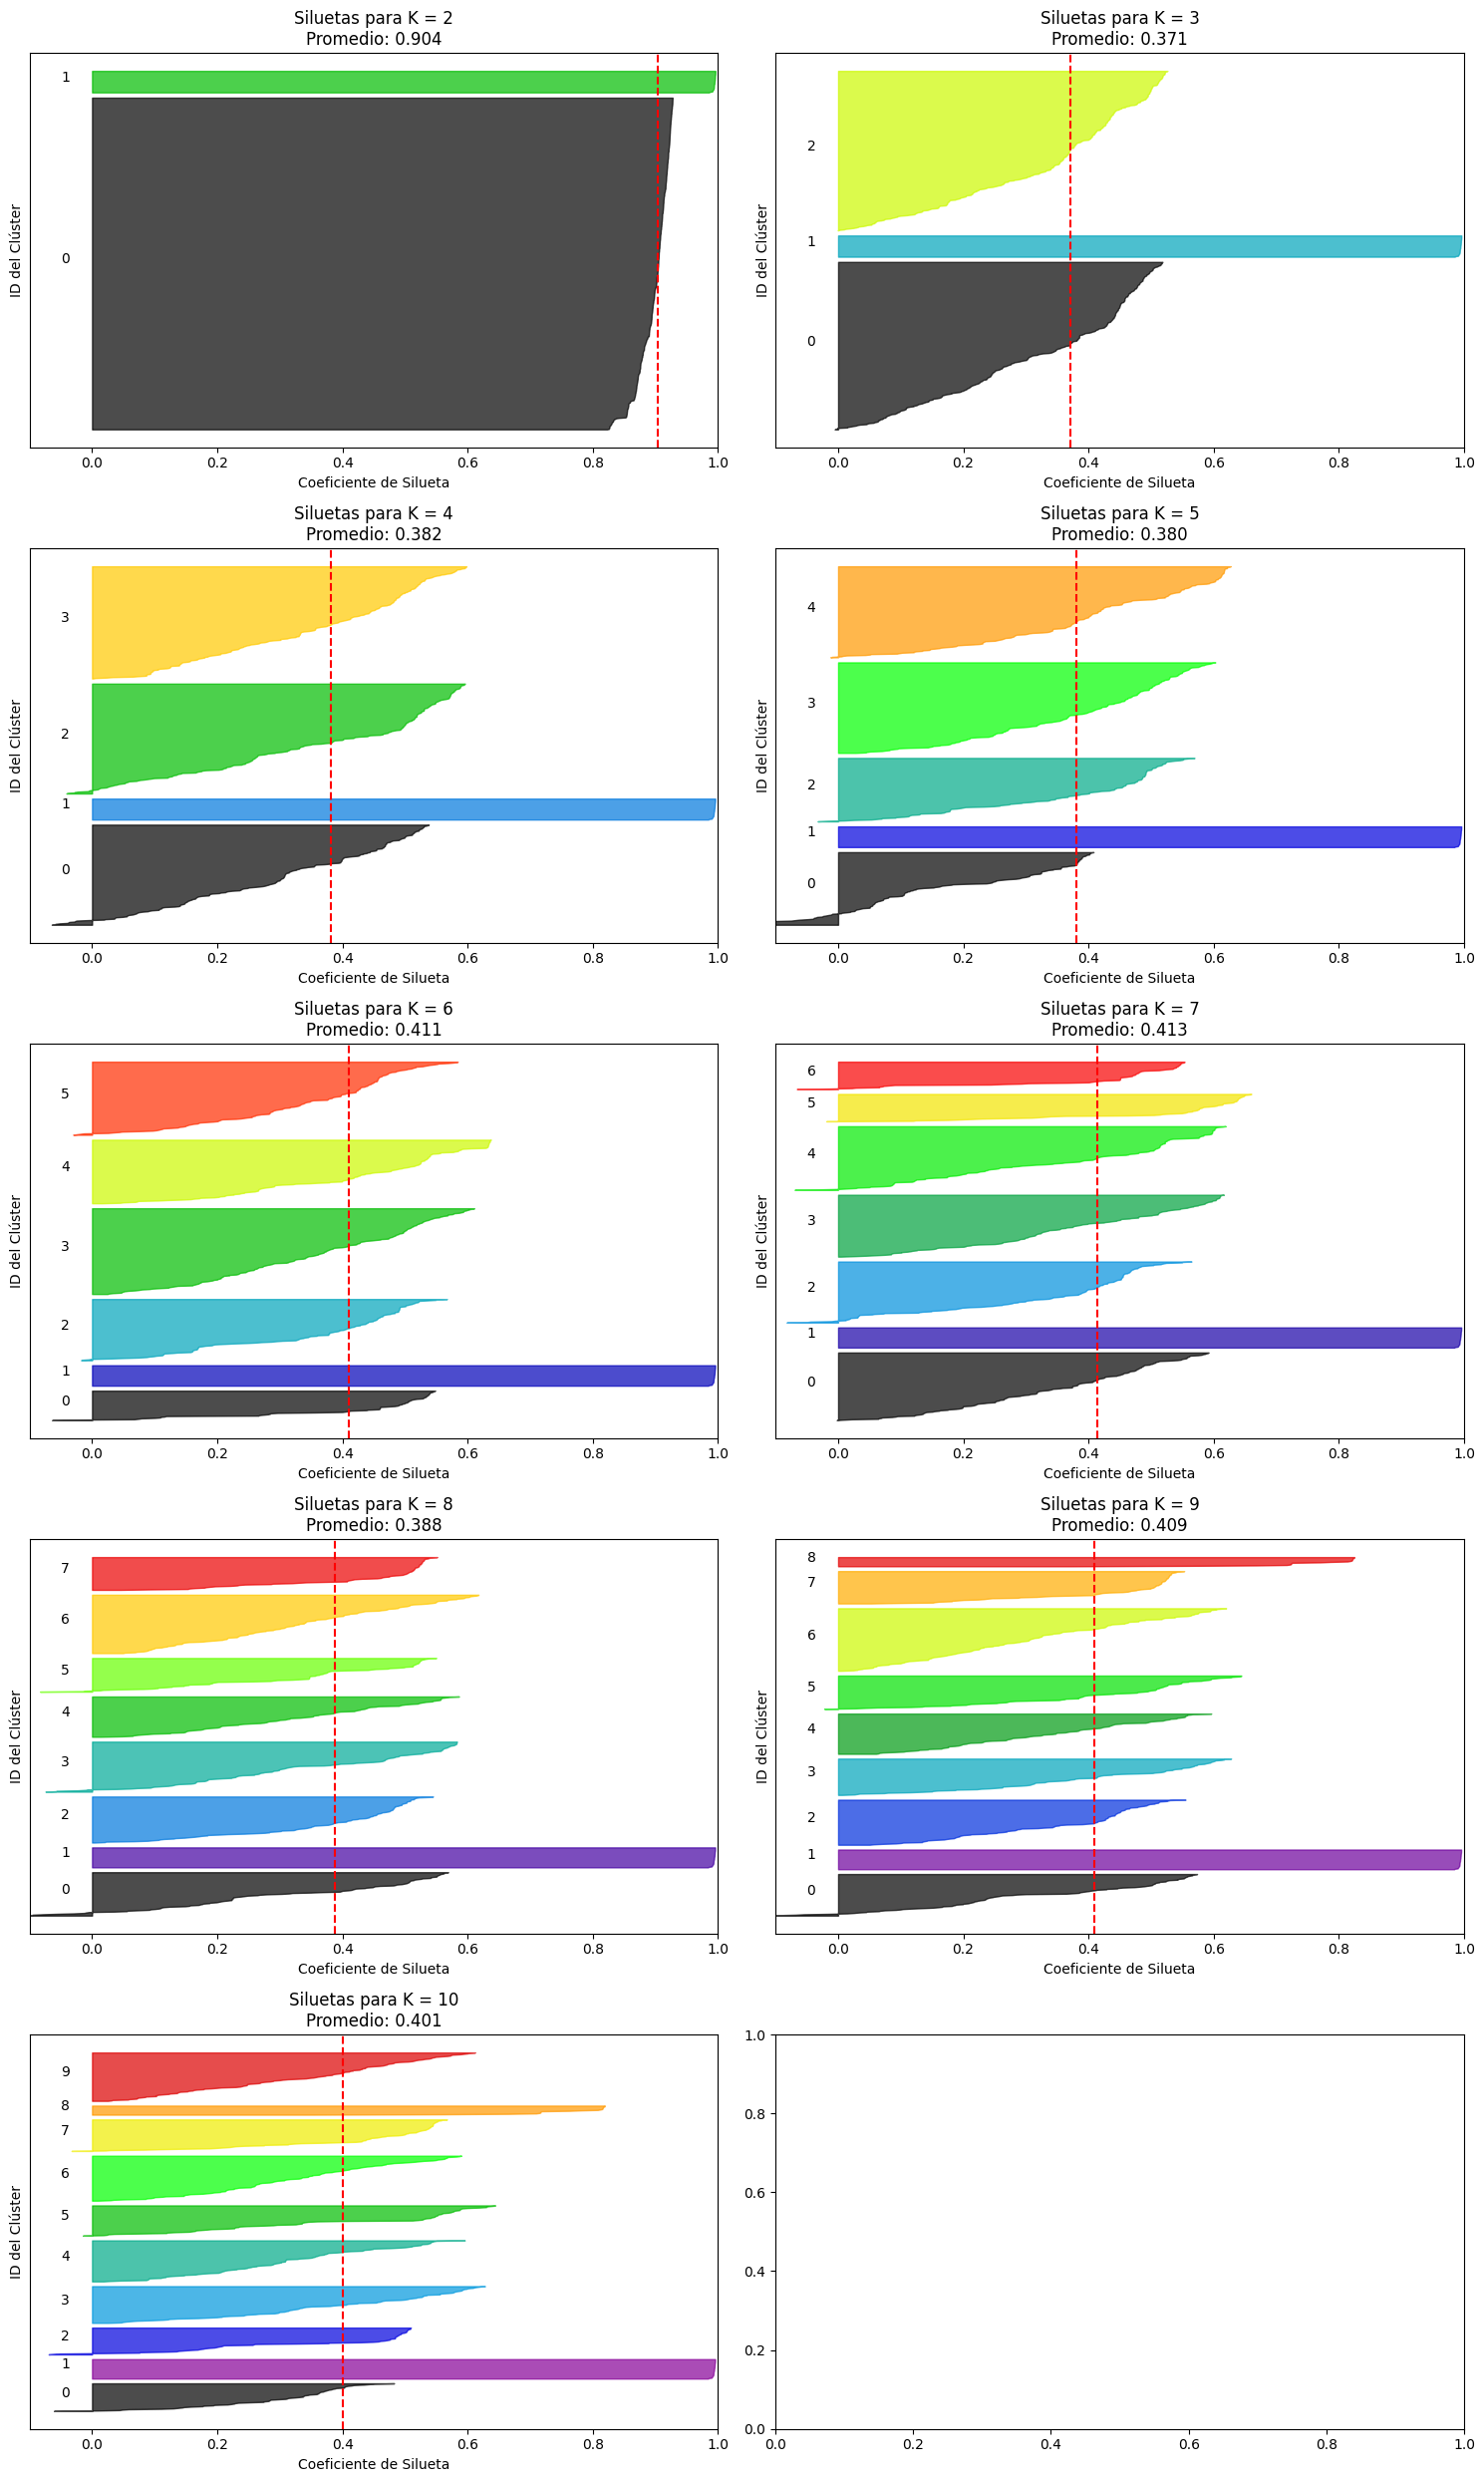

In [21]:
# import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples, silhouette_score

def graficar_analisis_siluetas(X, k_min, k_max):
    # Definir el rango de K a visualizar (seleccionamos unos pocos para no saturar)
    rango_interes = [k for k in range(k_min, k_max + 1)] # Solo pares para comparar
    
    n_rows = (len(rango_interes) + 1) // 2
    fig, axes = plt.subplots(n_rows, 2, figsize=(15, n_rows * 5))
    axes = axes.flatten()

    for i, k in enumerate(rango_interes):
        ax = axes[i]
        
        # Ajustar KMeans
        km = KMeans(n_clusters=k, random_state=31, n_init='auto')
        cluster_labels = km.fit_predict(X)
        
        # Score promedio
        silhouette_avg = silhouette_score(X, cluster_labels)
        # Valores de silueta para CADA punto
        sample_silhouette_values = silhouette_samples(X, cluster_labels)

        y_lower = 10
        for i_cluster in range(k):
            # Agrupar y ordenar valores del clúster
            ith_cluster_v = sample_silhouette_values[cluster_labels == i_cluster]
            ith_cluster_v.sort()

            size_cluster_i = ith_cluster_v.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i_cluster) / k)
            ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_v,
                             facecolor=color, edgecolor=color, alpha=0.7)

            # Etiquetar el clúster en el centro
            ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i_cluster))
            y_lower = y_upper + 10

        ax.set_title(f"Siluetas para K = {k}\nPromedio: {silhouette_avg:.3f}")
        ax.set_xlabel("Coeficiente de Silueta")
        ax.set_ylabel("ID del Clúster")

        # Línea vertical del promedio
        ax.axvline(x=silhouette_avg, color="red", linestyle="--")
        ax.set_yticks([])  # Limpiar ejes Y
        ax.set_xlim([-0.1, 1]) # Los valores van de -1 a 1

    plt.tight_layout()
    plt.show()

# Usar tu muestra para graficar
graficar_analisis_siluetas(X_2d, 2, 10)

In [22]:
K_OPTIMO = 8

km_final = KMeans(n_clusters=K_OPTIMO, random_state=31, n_init='auto')
df['cluster'] = km_final.fit_predict(X_svd)
print(df['cluster'].value_counts().sort_index())

cluster
0      3
1      1
2     14
3      1
4     36
5      1
6    661
7     24
Name: count, dtype: int64


In [23]:
vocab = np.array(tfidf.get_feature_names_out())
vocab

array(['abierto', 'aburrido', 'acción', 'acertijo', 'acertijos', 'acá',
       'ademas', 'adictivo', 'ahora', 'ahí', 'alguna', 'algún', 'alto',
       'ambientación', 'ambos', 'amor', 'amplio', 'and', 'antecesor',
       'anterior', 'anterior entrega', 'anteriormente', 'aparece',
       'apartado', 'aparte', 'aquí', 'arkham', 'arkham asylum',
       'arkham city', 'arkham knight', 'arkham origins', 'arte', 'asilo',
       'aspectos', 'asylum', 'así', 'aun', 'ayuda', 'año', 'años', 'aún',
       'aún así', 'banda', 'banda sonora', 'bastante', 'batman',
       'batman arkham', 'batman arkham asylum', 'batman arkham city',
       'batman mejor', 'best', 'best batman', 'bruce', 'bruce wayne',
       'brutal', 'buen', 'buena', 'buena historia', 'buenas', 'bueno',
       'bueno compralo', 'buenos', 'caballero', 'caballero noche',
       'caballero oscuro', 'cabe', 'cabeza', 'calidad', 'cambio',
       'campaña', 'campaña principal', 'cantidad', 'cariño', 'casi',
       'caso', 'catwoman', 'c

In [24]:
temas = {}
for c in range(K_OPTIMO):
    idx = df[df['cluster'] == c].index
    centroide_tfidf = X_tfidf[idx].mean(axis=0).A1
    top_idx = centroide_tfidf.argsort()[::-1][:10]
    top_terms = vocab[top_idx]
    temas[c] = ', '.join(top_terms)
    print(f'Cluster {c:2d} ({len(idx):5,} reseñas): {temas[c]}')

Cluster  0 (    3 reseñas): experiencia, sentir, gotham, arkham city, city, oscuro, caballero oscuro, universo batman, videojuego, universo
Cluster  1 (    1 reseñas): bastante, excelente, amplio, partida, visto, duración, obtener, importante, nuevo, perder
Cluster  2 (   14 reseñas): simplemente, hermoso, obra arte, batman, mejor, arte, obra, joya, trilogia, excelente
Cluster  3 (    1 reseñas): fin, anterior, día hoy, llena, desafios, diferentes, alto, merecido, giros, espectacular
Cluster  4 (   36 reseñas): batman, sos, the, gente, siempre, goty, vas, punto, chico, quiero
Cluster  5 (    1 reseñas): creo, ambientación, trama, compralo, primer, divertido, bastante, bueno, mejor, épico
Cluster  6 (  661 reseñas): historia, mejor, arkham, juegazo, bueno, batman, buen, asylum, buena, catwoman
Cluster  7 (   24 reseñas): mejor, mejor batman, batman, historia, definitivamente, saga, gatubela, jugabilidad historia, simplemente, goty mejor


## temas

In [25]:
ahora = datetime.utcnow()
hace_90 = ahora - timedelta(days=90)
hace_30 = ahora - timedelta(days=30)
sub      = df[df['cluster'] == c]
sub

C:\Users\ADRIA\AppData\Local\Temp\ipykernel_49164\1005906064.py:1: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ahora = datetime.utcnow()


,resena_id,resena_texto,recomendado,votos_utiles,fecha_creacion_unix,texto_limpio,umap_x,umap_y,cluster
67,208714462,el mejor juego de una grandiosa saga,1,0,1762608168,mejor grandiosa saga,-1.287872,3.836597,7
76,207566839,Aun me falta Arkham origins y apenas voy con Arkhan knight pero aun considero este el mejor videojuego de superheroes y el mejor juego de batman muy buena historia disfrute mucho el poder usar a gatubela y las peleas con jefes iconicas sin duda el mejor Batman (hasta ahora ya que todavia me faltan los otros 2),1,0,1761413113,aun falta arkham origins apenas voy arkhan knight aun considero mejor videojuego superheroes mejor batman buena historia disfrute poder usar gatubela peleas jefes iconicas duda mejor batman ahora todavia faltan,-2.948084,4.186018,7
84,205641975,El mejor juego de Batman de la Historia\r\nHistoria 8/10\r\nGameplay 10/10\r\nAmbientacion 9/10\r\nDLC'S 7/10,1,0,1759347771,mejor batman historia historia gameplay ambientacion dlc,-2.731179,4.320594,7
151,196717304,"De lo mejor, no solo de Batman, de superherores!",1,0,1749391214,mejor batman superherores,-2.882833,4.270631,7
159,195126673,"El mejor batman arkham que existe o he jugado. cómodo, agradable y a veces con los ajustes de dificultad adecuados retador (modo de juego del propio juego, no reglas absurdas de usuario)",1,0,1747549047,mejor batman arkham existe jugado cómodo agradable ajustes dificultad adecuados retador modo propio reglas absurdas usuario,-2.769747,4.150451,7
185,189525881,El mejor juego de batman,1,0,1741281665,mejor batman,-2.845668,4.226915,7
188,189388127,"tiene mas lore que los juegos actuales, God 10/10 Gatubela se mueve rico pero nadie es mejor que batman",1,0,1741124363,lore actuales god gatubela mueve rico nadie mejor batman,-2.953409,4.346746,7
208,186940045,Bro el mejor juego de batman ong ong fr fr,1,0,1738445342,bro mejor batman ong ong,-2.847711,4.249755,7
278,174238618,El mejor juego de Batman,1,0,1725489746,mejor batman,-2.823140,4.257607,7
292,169885556,el mejor fokin juego de todo fokin batman,1,0,1720995350,mejor fokin fokin batman,-1.423704,1.805188,7


In [26]:
import pandas as pd
from datetime import datetime, timedelta

df['fecha'] = pd.to_datetime(df['fecha_creacion_unix'], unit='s')

#LAs resñeas cambian con el tiempo, elegr de un mes y 3 meses
ahora = datetime.utcnow()
hace_90 = ahora - timedelta(days=90)
hace_30 = ahora - timedelta(days=30)

resumen = []


for c in range(K_OPTIMO):
    sub = df[df['cluster'] == c]
    
    # Filtros temporales
    sub_90 = sub[sub['fecha'] >= hace_90]
    sub_30 = sub[sub['fecha'] >= hace_30]

    resumen.append({
        'cluster':      c,
        'tema':         temas[c],
        'total':        len(sub),
        'pct_positivo': round(sub['recomendado'].mean() * 100, 1) if len(sub) > 0 else 0,
        'pct_pos_90d':  round(sub_90['recomendado'].mean() * 100, 1) if len(sub_90) > 0 else None,
        'pct_pos_30d':  round(sub_30['recomendado'].mean() * 100, 1) if len(sub_30) > 0 else None,
        'n_90d':        len(sub_90),
        'n_30d':        len(sub_30)
    })

df_resumen = pd.DataFrame(resumen).sort_values('total', ascending=False)

C:\Users\ADRIA\AppData\Local\Temp\ipykernel_49164\4092760952.py:7: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ahora = datetime.utcnow()


In [27]:
df_resumen

,cluster,tema,total,pct_positivo,pct_pos_90d,pct_pos_30d,n_90d,n_30d
6,6,"historia, mejor, arkham, juegazo, bueno, batman, buen, asylum, buena, catwoman",661,97.0,92.9,100.0,42,13
4,4,"batman, sos, the, gente, siempre, goty, vas, punto, chico, quiero",36,100.0,NaN,NaN,0,0
7,7,"mejor, mejor batman, batman, historia, definitivamente, saga, gatubela, jugabilidad historia, simplemente, goty mejor",24,100.0,NaN,NaN,0,0
2,2,"simplemente, hermoso, obra arte, batman, mejor, arte, obra, joya, trilogia, excelente",14,100.0,NaN,NaN,0,0
0,0,"experiencia, sentir, gotham, arkham city, city, oscuro, caballero oscuro, universo batman, videojuego, universo",3,100.0,NaN,NaN,0,0
1,1,"bastante, excelente, amplio, partida, visto, duración, obtener, importante, nuevo, perder",1,100.0,NaN,NaN,0,0
3,3,"fin, anterior, día hoy, llena, desafios, diferentes, alto, merecido, giros, espectacular",1,100.0,NaN,NaN,0,0
5,5,"creo, ambientación, trama, compralo, primer, divertido, bastante, bueno, mejor, épico",1,100.0,NaN,NaN,0,0


## Visualizaciones

In [28]:
df_plot = df.copy()
df_plot['cluster_str'] = df_plot['cluster'].astype(str)
df_plot['hover'] = df_plot['resena_texto'].str[:120]

fig = px.scatter(
    df_plot.sample(min(8000, len(df_plot)), random_state=31),
    x='umap_x', y='umap_y',
    color='cluster_str',
    hover_data={'hover': True, 'recomendado': True, 'umap_x': False, 'umap_y': False},
    opacity=1,
    width=900, height=600,
)
fig.update_traces(marker_size=5)
fig.show()

In [29]:
# Sentimiento total de los ultimos 90 dias
df_bar = df_resumen.dropna(subset=['pct_pos_90d']).copy()
df_bar['etiqueta'] = df_bar.apply(lambda r: f"C{r['cluster']}: {r['tema'][:40]}", axis=1)

fig = go.Figure()
fig.add_bar(name='Total', x=df_bar['etiqueta'], y=df_bar['pct_positivo'], marker_color='steelblue')
fig.add_bar(name='Últimos 90d', x=df_bar['etiqueta'], y=df_bar['pct_pos_90d'], marker_color='coral')
fig.update_layout(
    barmode='group',
    xaxis_tickangle=-35,
    yaxis_title='% recomendado',
    yaxis_range=[0, 100],
    width=950, height=500,
)
fig.show()

Con esta porimer areviusions e ve que IT-IDF no me ser muy uitl poruqe al tratar de careterizar por las palabras de la review me tope co eu parce que nmo es muy bueno viendo el contexto, ademas de que la comunidad de steam siendo la comunidad de steam tiene muchas formas variadas de expresarse, tendre que hacer una limpieza exaustyiva de la infroamcion


# Anslisi 2


In [30]:
query = """
        SELECT
            x.resena_id,
            x.juego_id,
            y.titulo,
            x.resena_texto,
            x.recomendado,
            x.votos_utiles,
            x.votos_graciosos,
            x.puntuacion_ponderada,
            x.minutos_al_resenar,
            x.minutos_totales,
            x.fecha_creacion_unix,
            x.autor_num_resenas,
            x.recibido_gratis,
            x.escrito_acceso_anticipado
        FROM hist_steam_reviews x
        JOIN cat_juego y ON x.juego_id = y.juego_id
        WHERE x.resena_texto IS NOT NULL
          AND TRIM(x.resena_texto) != ''
    """

In [31]:
df_reseñas=Query(query)

In [32]:
pd.set_option('display.max_colwidth', 100)
#df_reseñas

In [33]:
#cesnusar pero no borrar las palabras soeces que he detectado
NORMALIZACION_DE_intesidad={
    r'\bmierd[ao]s?\b':'expresion_negativa_fuerte',
    r'\bm[ie3]rd[ao]s?\b':'expresion_negativa_fuerte',#algunos usan numeros en vez de letras
    r'\bmrd\b':'expresion_negativa_fuerte',#
    r'\bchingad[ao]s?\b':'expresion_negativa_fuerte',
    r'\bpinch[eao]s?\b':'expresion_negativa_fuerte',
    r'\bjode[rte]?\b':'expresion_negativa_fuerte',

    r'\bputa\b':'expresion_negativa_fuerte',
    r'\bputo\b':'expresion_negativa_fuerte',

    r'\bhijo\s+de\s+(?:puta|perra)\b':'expresion_negativa_fuerte',

    r'\bbasura\b':'expresion_negativa_fuerte',
    r'\bporqueria\b':'expresion_negativa_fuerte',
    r'\bporquerías?\b':'expresion_negativa_fuerte',
 
    r'\bcarajo\b':'expresion_negativa_media',
    r'\bidiota\b':'expresion_negativa_media',
    r'\bimbécil\b':'expresion_negativa_media',
    r'\bboludo\b':'expresion_negativa_media',
    r'\bpedo\b':'expresion_negativa_media',
    r'\bpdo\b':'expresion_negativa_media',

    r'\bmamada\b':'expresion_media',


    r'\bpendejo\b':'expresion_negativa_media',
    r'\bgüev[oó]n\b':'expresion_negativa_media',
    r'\bcoño\b':'expresion_negativa_media',

    r'\bconcha\b':'expresion_negativa_media',

    r'\bhuev[oó]n\b':'expresion_negativa_media',
    r'\bculiao\b':'expresion_negativa_media',
    r'\bculos\b':'expresion_negativa_media',
    r'\bculonas\b':'expresion_negativa_media',
    r'\bweón\b':'expresion_negativa_media',
    r'\balv\b':'expresion_alta',

    r'z{3,}': 'expresion_aburrimiento',

    r'\b(ja|je|ji|js|ha|he|hi){2,}\b': ' expresion_risa ',
    r'(ja|je|ji|js|ha|he|hi){4,}': ' expresion_risa ',
    r'xd': ' expresion_risa ',
    r'verguear': 'golpear ',
 
    r'\bporonga\b':'contenido_irrelevante',
    r'\bpija\b':'contenido_irrelevante',
    r'\bverga\b':'expresion_media',
    r'\bchupar?\b':'contenido_irrelevante',
    r'\bsex[uo]\b':'contenido_irrelevante',
    r'\bcojer\b':'contenido_irrelevante',
    r'\btetas\b':'contenido_irrelevante',
    r'\btetonas\b':'contenido_irrelevante',
    r'\bcoger\b':'contenido_irrelevante',
    r'\bpaja\b':'contenido_irrelevante',
    r'\bcagada\b':'expresion_negativa_media', 
 
    r'\bjuegazo\b':'expresion_positiva_fuerte',
    r'\bperfectazo\b':'expresion_positiva_fuerte',
    r'\bgenius?\b':'expresion_positiva_media',
    r'\bmaestro\b':'expresion_positiva_media',
}

In [34]:
PATRONES_RUIDO = [
    (r'\[\/?\w+\]',' '),  # [h1] [b], [/h1]
    (r'http\S+|www\.\S+',' '),  # links
    (r'<[^>]+>',' '),  # htmls
    (r'&\w+;',' '), 
    (r'[\u2580-\u259F\u25A0-\u25FF\u2600-\u26FF\u2700-\u27BF]', ' '), #muchos usan ascii para hacer images
    (r'[★☆♥♦♠♣]',' '), #sibolos decorativos comunes en Steam}

    (r'\.{3,}','...'), # puntos excesivos
    (r'!{2,}','!'),
    (r'\?{2,}','?'),
    (r'-{3,}',' '),
    (r'={3,}',' '),
    (r'_{3,}',' '),
    
    (r'\n+',' '),   # saltos de linea y de tabulacion
    (r'\t+',' '),]

In [35]:
df_reseñas['votos_graciosos'].value_counts().head(30)


votos_graciosos
0     504466
1      34144
2       8166
3       3441
4       1823
5       1142
6        750
7        565
8        433
9        292
10       235
11       221
12       141
13       123
15       110
14       107
16        92
17        79
20        66
19        64
23        53
18        50
22        44
25        41
21        39
24        34
28        31
26        27
27        27
29        24
Name: count, dtype: int64

In [36]:
pd.set_option('display.max_colwidth', 300)
#df_reseñas[df_reseñas['votos_graciosos']>105]
df_reseñas[df_reseñas['votos_graciosos']==1].sample()


,resena_id,juego_id,titulo,resena_texto,recomendado,votos_utiles,votos_graciosos,puntuacion_ponderada,minutos_al_resenar,minutos_totales,fecha_creacion_unix,autor_num_resenas,recibido_gratis,escrito_acceso_anticipado
76818,214989100,1743,Ultrakill,"Estuve esperando 2 años para poder jugar está joya,sin duda uno de mis shooters favoritos. Porfavor hakita,ven a Latinoamérica para que te dé una buena cromada de rifle de tan bueno que es UltraKill",1,1,1,0.484375,56,231.0,1767417209,1,0,1


In [37]:
def filtrar_por_votos_graciosos(df, umbral = 10):
    antes = len(df)
    df = df[df['votos_graciosos'] < umbral].copy()
    print(f"Eliimnadas: {antes - len(df):,}, Quedan: {len(df):,}")
    return df

In [38]:
df_reseñas = filtrar_por_votos_graciosos(df_reseñas, 10)
#df_reseñas

Eliimnadas: 1,962, Quedan: 555,222


In [39]:
#Yas e quedarojn las mas serias pero aun tiene mucha basura
# hay muchos emojis que se peuden expresar como texto

def normalizar_emojis(texto):
    texto = emoji.demojize(texto, language='es')
    texto = re.sub(r':([a-z_áéíóúü]+):', r' \1 ', texto)
    return texto

In [40]:
#por meme o ahce un tiempo las opciones tienden a ponerlo 9 de 10, 100/ de 10., 7 de 10 a sus opioniones, con
# ellas puedo dar un valor cuantificado que da la review pero aun con el sesgo de que tan objetivo es la review
PATRON_CALIFICACION = re.compile(
    r'\b(\d{1,4}(?:[.,]\d+)?)\s*(?:[\/]|de|[\/]\s*de)\s*(\d{1,4})\b',
    re.IGNORECASE
)

def normalizar_calificaciones(texto):
    def reemplazar(m):
        num = m.group(1).replace(',', '.').replace('.', '_')
        den = m.group(2)
        return f'calificacion_{num}_{den}'
    return PATRON_CALIFICACION.sub(reemplazar, texto)

In [41]:
#muchos parad ar enfasis dan muchas vocales para expresar mejor la respuesta
def reducir_caracteres_repetidos(texto):
    return re.sub(r'(.)\1{2,}', r'\1\1', texto)

In [42]:
#hay mucahs palabras que escriben con de esta forma. H.o.rr.i.b.l.e y eso ahce que no se encuentren
def unificar_palabras_punteadas(texto):
    def de_puntos_a_palabra(m):
        return m.group(0).replace('.', '')

    patron = r'\b(?:[a-záéíóúüñ]\.){2,}[a-záéíóúüñ]\b'
    return re.sub(patron, de_puntos_a_palabra, texto, flags=re.IGNORECASE)

In [ ]:
def limpiar_texto(texto):
    if not isinstance(texto, str) or not texto.strip():
        return ''

    # 1. Normalizar emojis y ruido técnico primero
    texto = normalizar_emojis(texto)
    for patron, reemplazo in PATRONES_RUIDO:
        texto = re.sub(patron, reemplazo, texto)

    texto = unificar_palabras_punteadas(texto)

    texto = normalizar_calificaciones(texto)

    texto = texto.lower()

    for patron, reemplazo in NORMALIZACION_DE_intesidad.items():
        texto = re.sub(patron, reemplazo, texto) # Ya no hace falta el flag IGNORECASE aquí

    texto = reducir_caracteres_repetidos(texto)

    texto = re.sub(r"[^a-záéíóúüñ\s0-9.,!?\-_()'\"_]", ' ', texto)

    texto = re.sub(r'\s+', ' ', texto).strip()

    return texto

In [44]:
df_reseñas['resena_limpia'] = df_reseñas['resena_texto'].apply(limpiar_texto)

In [45]:
df_reseñas.shape

(555222, 15)

In [46]:
df_reseñas[['titulo','resena_limpia','resena_texto']].sample(5)


,titulo,resena_limpia,resena_texto
248419,Gang Beasts,"muy divertido la verdad, para jugar con amigo va genial","Muy divertido la verdad, para jugar con amigo va genial"
177104,Cookie Clicker,galleta dorso_de_mano_con_índice_hacia_arriba_tono_de_piel_claro galleta dorso_de_mano_con_índice_hacia_arriba_tono_de_piel_claro galleta dorso_de_mano_con_índice_hacia_arriba_tono_de_piel_claro galleta dorso_de_mano_con_índice_hacia_arriba_tono_de_piel_claro galleta dorso_de_mano_con_índice_hac...,🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆🏻🍪👆...
522085,Granny: Chapter Two,expresion_negativa_fuerte juego de expresion_negativa_fuerte ojala se joda el gradpa y la granny jodanse quiero seme,pinche juego de mierda ojala se joda el gradpa y la granny jodanse quiero seme
479131,Bug Fables: The Everlasting Sapling,delicioso,delicioso\n
528923,Smite,es un buen juego con dioses. calificacion_9_10 porque le falta un dios en particular.. mercedes sosa,Es un buen juego con dioses. \n9/10 porque le falta un dios en particular... Mercedes Sosa


In [47]:
df_reseñas[df_reseñas['resena_limpia'].str.split().str.len() < 5].sample(5)

,resena_id,juego_id,titulo,resena_texto,recomendado,votos_utiles,votos_graciosos,puntuacion_ponderada,minutos_al_resenar,minutos_totales,fecha_creacion_unix,autor_num_resenas,recibido_gratis,escrito_acceso_anticipado,resena_limpia
485099,112968188,3182,Yu-Gi-Oh! Legacy of the Duelist,a,1,0,0,0.5,3581,4751.0,1648473652,23,0,0,a
478789,160081501,2793,Haven,god si estas soltero,1,0,0,0.5,210,303.0,1709874061,72,0,0,god si estas soltero
529136,69422636,738,Smite,.,1,0,0,0.5,35547,95697.0,1589897494,5,0,0,.
169068,103594590,729,Grim Dawn,Josha!!,1,0,0,0.5,3907,5398.0,1637800114,2,0,0,josha!
208500,66132115,317,To the Moon,8/10,1,0,0,0.5,284,350.0,1585535875,79,0,0,calificacion_8_10


In [48]:
def filtrar_por_longitud(df, min_palabras=5, max_palabras=1500):
    antes = len(df)
    conteo = df['resena_limpia'].str.split().str.len()
    df = df[(conteo >= min_palabras) & (conteo <= max_palabras)].copy()
    print(f"{antes - len(df)}, me quedan: {len(df)}")
    return df

In [49]:
df_reseñas = filtrar_por_longitud(df_reseñas, 10, 1500)

246740, me quedan: 308482


In [50]:
df_reseñas[['titulo','resena_limpia','resena_texto']].sample(5)

,titulo,resena_limpia,resena_texto
263789,Outriders,todavia es la hora que no puedo continuar el juego ni recuperar mi personaje porque el juego tira demaciados errores y me bota,Todavia es la hora que no puedo continuar el juego ni recuperar mi personaje porque el juego tira demaciados errores y me bota
479721,Felvidek,"muy weno, muy parecido al hylics y mejor en varios aspectos, ost god haganle secuela porfavor.","muy weno, muy parecido al hylics y mejor en varios aspectos, ost god\n\nhaganle secuela porfavor."
253214,BioShock Remastered,gran historia pero la batalla final es mas facil que la chucha expresion_risa,gran historia pero la batalla final es mas facil que la chucha XD
40735,No Man's Sky,expresion_negativa_fuerte expresion_positiva_fuerte es uno de los mejores juegos que he jugado y de paso puedo jugarlo con amigos (le suma bastante puntos),Pinche juegazo es uno de los mejores juegos que he jugado y de paso puedo jugarlo con amigos (le suma bastante puntos)
27664,DayZ,"un juego cuyo unico fin es trolear o ser troleado, ya no importa si sos el mas chetado del sv, tenes que matar bambis sea como sea. ademas esta bien optimizado. calificacion_10_10 gg goty ez","un juego cuyo unico fin es trolear o ser troleado, ya no importa si sos el mas chetado del sv, tenes que matar bambis sea como sea.\nademas esta bien optimizado.\n10/10 gg goty ez\n"


In [51]:
STOPWORDS_BASICAS = {'de','que','a','la','el','en','y','con','los','las','un','una','por','es','se'}
def filtrar_por_repeticion(df, umbral=0.35):
    def es_repetitiva(texto):
        palabras = str(texto).lower().split()
        if len(palabras) < 5: return False
        
        filtradas = [p for p in palabras if p not in STOPWORDS_BASICAS]
        if not filtradas: return False
        
        # Uso de Counter para mayor velocidad
        mas_comun_count = Counter(filtradas).most_common(1)[0][1]
        return (mas_comun_count / len(palabras)) > umbral

    return df[~df['resena_limpia'].apply(es_repetitiva)].copy()

In [52]:
df_reseñas = filtrar_por_repeticion(df_reseñas, .35)

In [53]:
df_reseñas[['titulo','resena_limpia','resena_texto']].sample(5)

,titulo,resena_limpia,resena_texto
552923,Aimlabs,"es bueno para calentar la mano antes de entrar a jugar un shooter, le dedique 3 horitas y fuera de bromas me ayudo a mantener mas precision en la mano y reaccion mas rapida y apuntar mas rapido","es bueno para calentar la mano antes de entrar a jugar un shooter, le dedique 3 horitas y fuera de bromas me ayudo a mantener mas precision en la mano y reaccion mas rapida y apuntar mas rapido"
48104,Dark Souls III,"la verdad es uno de mis juegos favoritos con toda la saga souls, me encantaron los dlc me parece mas frenetico y perfecto para empezar y adentarse en esta magnfica saga, gracias al tremendo tracero de la bailarina","la verdad es uno de mis juegos favoritos con toda la saga souls, me encantaron los DLC me parece mas frenetico y perfecto para empezar y adentarse en esta magnfica saga, gracias al tremendo tracero de la bailarina"
36643,Sea of Thieves,buen juego ya sea para jugar solo o con amigos,Buen juego ya sea para jugar solo o con amigos
337304,Alice: Madness Returns,"experiencia artistica muy bonita que solo pudo ocurrir bajo la direccion de alguien apasionado y con el financiamento de una de las peores megacorporaciones del gaming. la historia nunca será concluida en juego, asi que por favor concluir leyendo el pdf de alice asylum para recibir un final sati...","Experiencia artistica muy bonita que solo pudo ocurrir bajo la direccion de alguien apasionado y con el financiamento de una de las peores megacorporaciones del gaming. La historia nunca será concluida en juego, asi que por favor concluir leyendo el PDF de Alice Asylum para recibir un final sati..."
146880,Hotline Miami,es entretenimiento de principio a fin y con una trama mas profunda de lo que parece. recomendado 100,Es entretenimiento de principio a fin y con una trama mas profunda de lo que parece. Recomendado 100%


In [54]:
def es_espanol(texto):
    try:
        return detect(texto) == 'es'
    except:
        return False

df_reseñas = df_reseñas[df_reseñas['resena_limpia'].apply(es_espanol)]

In [55]:
# ms limpeiza porque en los clsuteres se encontraon varias frases comunes de meme y se aguraparona ahi
FRASES_MEME = [
    "la vida de un crítico es sencilla",
    "dijo que si publico una reseña",
    "para el ciego, es la luz",
    "para el ciego es la luz",
    "tiene un millón de haters",
    "los pelos de los huevos",
    "los pelos de los webos",
    "ojala el dia que la ponga",
    "ojalá el día que la ponga",
    "ojala cuando haga el tuxi",
    "cuando haga el tuxi tuxi",
    "ojala tener una polola sea",
    "mucho contenido_irrelevante a toda hora",
]
 
FRASES_RECETA = [
    "ingredientes",
    "harina",
    "sal",
    "aceite",
    "azúcar",
    "masa",
]
 
TOKENS_FORMATO = [
    "marca_de_cruz",
    "marca_de_verificación",
    "botón_de_marca_de_verificación",
    "casilla_con_marca_de_verificación",
    "botón_cuadrado_con_borde_blanco",
    "botón_cuadrado_con_borde_negro",
]

In [56]:
def es_meme(texto):
    t = texto.lower()
    return any(frase in t for frase in FRASES_MEME)

In [57]:
def es_receta(texto):
    t = texto.lower()
    palabras = t.split()
    hits = sum(1 for f in FRASES_RECETA if f in t)
    return hits >= 3 and len(palabras) > 30

In [58]:
def es_puro_formato(texto, umbral= 0.35):
    palabras = texto.lower().split()
    if len(palabras) < 8:
        return False
    hits = sum(1 for p in palabras if any(tok in p for tok in TOKENS_FORMATO))
    return (hits / len(palabras)) > umbral

In [59]:
def filtrar_post_clustering(df):
    antes = len(df)
 
    mask_meme     = df['resena_limpia'].apply(es_meme)
    mask_receta   = df['resena_limpia'].apply(es_receta)
    mask_formato  = df['resena_limpia'].apply(es_puro_formato)
 
    mask_ruido = mask_meme | mask_receta | mask_formato
 
    print(f"[POST-FILTRO] Memes detectados:         {mask_meme.sum():,}")
    print(f"[POST-FILTRO] Recetas detectadas:        {mask_receta.sum():,}")
    print(f"[POST-FILTRO] Solo formato (checkboxes): {mask_formato.sum():,}")
    print(f"[POST-FILTRO] Total a eliminar:          {mask_ruido.sum():,}")
 
    df = df[~mask_ruido].copy()
    print(f"me quedaron {len(df):,} reseñas")
    return df

In [60]:
print(f"{len(df):,}")

741


In [61]:
df_reseñas = filtrar_post_clustering(df_reseñas)

[POST-FILTRO] Memes detectados:         611
[POST-FILTRO] Recetas detectadas:        247
[POST-FILTRO] Solo formato (checkboxes): 2
[POST-FILTRO] Total a eliminar:          860
me quedaron 295,974 reseñas


In [ ]:
df_reseñas.to_parquet("../parquet/resenas_limpias.parquet", index=False)

NameError: name 'df_reseñas' is not defined